In [1]:
import os

import numpy as np
import pandas as pd 
from pyecharts.charts import *
from pyecharts import options as opts
import seaborn as sns

In [2]:
from pyecharts.globals import CurrentConfig, OnlineHostType
CurrentConfig.ONLINE_HOST = OnlineHostType.NOTEBOOK_HOST

In [4]:
from utils.data_path import root_path

df = pd.read_excel(os.path.join(root_path(), 'data/user/from/订单明细.xlsx'))
df.head()

,订单编号,用户编号,交易时间,交易状态,数量,金额
0,A0001,U0001,2021-01-22 00:17:59,交易成功,2,279.0
1,A0002,U0002,2021-01-22 00:59:54,交易成功,2,217.5
2,A0003,U0003,2021-01-22 07:48:48,交易成功,2,291.0
3,A0004,U0004,2021-01-22 09:15:49,退款成功,2,126.0
4,A0005,U0005,2021-01-22 09:59:33,退款成功,2,111.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28832 entries, 0 to 28831
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   订单编号    28832 non-null  object        
 1   用户编号    28832 non-null  object        
 2   交易时间    28832 non-null  datetime64[ns]
 3   交易状态    28832 non-null  object        
 4   数量      28832 non-null  int64         
 5   金额      28832 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 1.3+ MB


In [6]:
df['交易状态'].unique()

array(['交易成功', '退款成功'], dtype=object)

In [6]:
df = df.loc[df['交易状态'] == '交易成功']

In [7]:
df = df[['用户编号', '交易时间', '金额']]

In [8]:
df.head(10)

,用户编号,交易时间,金额
0,U0001,2021-01-22 00:17:59,279.0
1,U0002,2021-01-22 00:59:54,217.5
2,U0003,2021-01-22 07:48:48,291.0
5,U0006,2021-01-22 10:00:07,295.5
6,U0007,2021-01-22 10:00:08,252.0
7,U0008,2021-01-22 10:00:11,181.5
8,U0009,2021-01-22 10:00:14,316.5
9,U0010,2021-01-22 11:41:02,255.0
10,U0011,2021-01-22 12:08:49,186.0
11,U0012,2021-01-22 12:22:16,370.5


# R(近期交易时间)

- 最近一次交易时间距离统计日期的天数

In [9]:
start_data = df['交易时间'].max()
start_data

Timestamp('2021-07-21 22:46:22.511000')

In [10]:
# 求每个用户最后一次交易时间
r = df.groupby('用户编号')['交易时间'].max().reset_index()
r.head()

,用户编号,交易时间
0,U0001,2021-01-22 00:17:59
1,U0002,2021-01-22 00:59:54
2,U0003,2021-01-22 07:48:48
3,U0005,2021-02-01 08:12:15
4,U0006,2021-02-01 23:19:23


In [11]:
r['R'] = (start_data-r['交易时间']).dt.days
r = r[['用户编号', 'R']]
r.head()

,用户编号,R
0,U0001,180
1,U0002,180
2,U0003,180
3,U0005,170
4,U0006,169


# F(交易频次)

- 当天多次交易仅计算一次

In [12]:
# 以用户编号分组对交易时间去重计数
# df.groupby('用户编号').agg(F=('交易日期', 'nunique')).reset_index()
f = df.groupby('用户编号', as_index=False).agg(F=('交易时间', 'nunique'))
f.head(10)

,用户编号,F
0,U0001,1
1,U0002,1
2,U0003,1
3,U0005,1
4,U0006,2
5,U0007,2
6,U0008,1
7,U0009,3
8,U0010,1
9,U0011,1


# M(交易金额)

In [13]:
m = df.groupby('用户编号', as_index=False).agg(M=('金额', 'sum'))
m.head()

,用户编号,M
0,U0001,279.0
1,U0002,217.5
2,U0003,291.0
3,U0005,108.0
4,U0006,651.0


# RFM合并

In [14]:
# merge(左右内外交叉)\join(左右内外)\concat(内外)
rfm = r.merge(f, on='用户编号').merge(m, on='用户编号')
rfm.head()
# pd.merge(r, f, on='用户编号')

,用户编号,R,F,M
0,U0001,180,1,279.0
1,U0002,180,1,217.5
2,U0003,180,1,291.0
3,U0005,170,1,108.0
4,U0006,169,2,651.0


# RFM均值

<AxesSubplot:xlabel='R', ylabel='Density'>

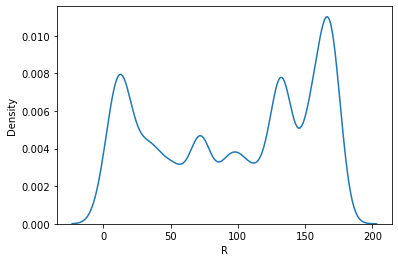

In [15]:
# 越接近零越对称
rfm['R'].skew()
# -0.23497860252734598
sns.kdeplot(x=rfm['R'])

<AxesSubplot:xlabel='F', ylabel='Density'>

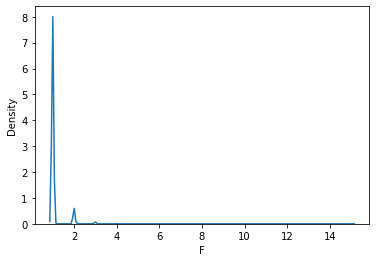

In [16]:
rfm['F'].skew()
# 4.623659633018703
sns.kdeplot(x=rfm['F'])

<AxesSubplot:xlabel='M', ylabel='Density'>

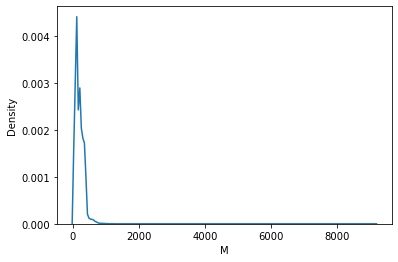

In [17]:
rfm['M'].skew()
# 14.15870871182295
sns.kdeplot(x=rfm['M'])

In [18]:
rfm.describe().round(2)

,R,F,M
count,25419.00,25419.00,25419.00
mean,97.04,1.09,207.20
std,58.45,0.34,144.89
min,0.00,1.00,45.00
25%,37.00,1.00,114.00
50%,105.00,1.00,186.00
75%,154.00,1.00,286.50
max,180.00,15.00,9136.50


In [19]:
# R指标的均值
AVG_R = rfm['R'].mean()
# F指标的均值
AVG_F = rfm['F'].mean()
# M指标的均值
AVG_M = rfm['M'].mean()

In [20]:
# 100\10\1用于分类
rfm['R_score'] = (rfm['R'] < AVG_R)*100
rfm['F_score'] = (rfm['F'] > AVG_F)*10
rfm['M_score'] = (rfm['M'] > AVG_M)*1

In [21]:
# 总分值
rfm['Total_score'] = rfm['R_score']+rfm['F_score']+rfm['M_score']
rfm.head()

,用户编号,R,F,M,R_score,F_score,M_score,Total_score
0,U0001,180,1,279.0,0,0,1,1
1,U0002,180,1,217.5,0,0,1,1
2,U0003,180,1,291.0,0,0,1,1
3,U0005,170,1,108.0,0,0,0,0
4,U0006,169,2,651.0,0,10,1,11


# 标签映射

In [22]:
rfm['Total_score'].unique()

array([  1,   0,  11, 111, 100,  10, 110, 101], dtype=int32)

In [23]:
dct = {111: '重要价值',
       110: '一般价值',
       101: '重要发展',
       100: '一般发展',
       11: '重要保持',
       10: '一般保持',
       1: '重要挽留',
       0: '一般挽留'}

In [24]:
rfm['用户标签'] = rfm['Total_score'].map(dct)

In [25]:
rfm['用户标签'].unique()

array(['重要挽留', '一般挽留', '重要保持', '重要价值', '一般发展', '一般保持', '一般价值', '重要发展'],
      dtype=object)

In [26]:
rfm.head()

,用户编号,R,F,M,R_score,F_score,M_score,Total_score,用户标签
0,U0001,180,1,279.0,0,0,1,1,重要挽留
1,U0002,180,1,217.5,0,0,1,1,重要挽留
2,U0003,180,1,291.0,0,0,1,1,重要挽留
3,U0005,170,1,108.0,0,0,0,0,一般挽留
4,U0006,169,2,651.0,0,10,1,11,重要保持


# 各类用户占比

In [34]:
cnt = rfm['用户标签'].value_counts().reset_index()
cnt

,index,用户标签
0,一般挽留,7768
1,一般发展,5936
2,重要挽留,5156
3,重要发展,4533
4,重要价值,1105
5,重要保持,567
6,一般价值,252
7,一般保持,102


In [35]:
# 各类用户的人数统计
cnt = rfm['用户标签'].value_counts().reset_index()
cnt.columns = ['用户标签', '人数']
cnt['人数占比'] = cnt['人数'] / cnt['人数'].sum()
cnt

,用户标签,人数,人数占比
0,一般挽留,7768,0.305598
1,一般发展,5936,0.233526
2,重要挽留,5156,0.202840
3,重要发展,4533,0.178331
4,重要价值,1105,0.043471
5,重要保持,567,0.022306
6,一般价值,252,0.009914
7,一般保持,102,0.004013


In [36]:
# 各类用户的金额统计
amt = rfm.groupby('用户标签', as_index=False)['M'].sum()
amt.columns = ['用户标签', '金额']
amt['金额占比'] = amt['金额'] / amt['金额'].sum()
amt

,用户标签,金额,金额占比
0,一般价值,38247.0,0.007262
1,一般保持,16194.0,0.003075
2,一般发展,695890.5,0.132128
3,一般挽留,888801.0,0.168756
4,重要价值,522940.5,0.099290
5,重要保持,244242.0,0.046374
6,重要发展,1337377.5,0.253927
7,重要挽留,1523080.5,0.289187


In [37]:
tb = pd.merge(cnt, amt, on='用户标签')
tb['人数占比'] = tb['人数占比'].apply(lambda x: '{:.2%}'.format(x))
tb['金额占比'] = tb['金额占比'].apply(lambda x: '{:.2%}'.format(x))
tb.sort_values(by=['金额', '人数'], ascending=[False, False], inplace=True)
tb

,用户标签,人数,人数占比,金额,金额占比
2,重要挽留,5156,20.28%,1523080.5,28.92%
3,重要发展,4533,17.83%,1337377.5,25.39%
0,一般挽留,7768,30.56%,888801.0,16.88%
1,一般发展,5936,23.35%,695890.5,13.21%
4,重要价值,1105,4.35%,522940.5,9.93%
5,重要保持,567,2.23%,244242.0,4.64%
6,一般价值,252,0.99%,38247.0,0.73%
7,一般保持,102,0.40%,16194.0,0.31%


In [43]:
del tb['金额占比']
tb

,用户标签,人数,人数占比,金额
2,重要挽留,5156,20.28%,1523080.5
3,重要发展,4533,17.83%,1337377.5
0,一般挽留,7768,30.56%,888801.0
1,一般发展,5936,23.35%,695890.5
4,重要价值,1105,4.35%,522940.5
5,重要保持,567,2.23%,244242.0
6,一般价值,252,0.99%,38247.0
7,一般保持,102,0.40%,16194.0


# 可视化

In [49]:
pie = Pie(init_opts=opts.InitOpts(width='1100px', height='500px'))
pie.add(
    '交易金额',
    tb[['用户标签', '金额']].values.tolist(),
    radius=['20%', '70%'],
    # 第一项为宽度,第二项为高度
    center=['25%', '50%'],
    rosetype='radius'
)
pie.set_series_opts(label_opts=opts.LabelOpts(formatter='{b}{d}%'))
pie.add(
    '交易人数',
    tb[['用户标签', '人数']].values.tolist(),
    radius=['20%', '70%'],
    # 第一项为宽度,第二项为高度
    center=['75%', '50%'],
    rosetype='radius'
)
pie.render('RFM模型分析.html')
pie.render_notebook()

In [45]:
# 各区域的RFM模型分析
user = pd.read_excel('data/用户信息.xlsx')
user.head()

,用户编号,省份,区域,大区
0,U0001,上海,华东,南区
1,U0002,广东,中南,南区
2,U0003,山东,华东,南区
3,U0004,江苏,华东,南区
4,U0005,上海,华东,南区


In [51]:
rfm_user = rfm.merge(user, on='用户编号')[['用户编号', '用户标签', '区域', 'M']]
rfm_user.head()

,用户编号,用户标签,区域,M
0,U0001,重要挽留,华东,279.0
1,U0002,重要挽留,中南,217.5
2,U0003,重要挽留,华东,291.0
3,U0005,一般挽留,华东,108.0
4,U0006,重要保持,华东,651.0


In [55]:
# 各区域内各类用户的人数和金额统计
tb2 = rfm_user.groupby(['区域', '用户标签']).agg(人数=('用户编号', 'count'), 金额=('M', 'sum')).reset_index()
tb2.sort_values(['金额','人数'], ascending = [False, False], inplace = True)
tb2.head()

,区域,用户标签,人数,金额
23,华东,重要挽留,2280,672448.5
22,华东,重要发展,2041,604053.0
19,华东,一般挽留,3653,413959.5
15,中南,重要挽留,1156,343150.5
18,华东,一般发展,2749,325111.5


In [56]:
# 选项卡多图, 每个区域一个图表
tab = Tab()
for i in tb2['区域'].unique():
    # print(i)
    data = tb2[tb2['区域'] == i]
    pie = Pie(init_opts=opts.InitOpts(width='1100px', height='500px'))
    pie.add(
        '交易金额',
        data[['用户标签', '金额']].values.tolist(),
        radius=['20%', '70%'],
        # 第一项为宽度,第二项为高度
        center=['25%', '50%'],
        rosetype='radius'
    )
    pie.add(
        '交易人数',
        data[['用户标签', '人数']].values.tolist(),
        radius=['20%', '70%'],
        # 第一项为宽度,第二项为高度
        center=['75%', '50%'],
        rosetype='radius'
    )
    pie.set_series_opts(label_opts=opts.LabelOpts(formatter='{b}{d}%'))
    tab.add(pie, i)
tab.render('RFM模型分析-区域.html')
tab.render_notebook()